In [2]:
# Exploratory Data Analysis (EDA)

## Financial Risk Analytics

### Objective
# The purpose of Exploratory Data Analysis (EDA) is to identify patterns, trends, relationships, and anomalies in the Home Credit loan dataset. 
# These insights help understand the factors influencing loan default risk and support data-driven decision-making.

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [49]:
df = pd.read_csv("cleaned_application_train.csv")

In [50]:
df.shape

(307511, 105)

In [51]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
## Analysis 1: Loan Default Distribution

# The TARGET column indicates whether a customer defaulted on the loan.

# - 0 → Loan Repaid
# - 1 → Loan Default

In [53]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [54]:
round(df["TARGET"].value_counts(normalize=True) * 100, 2)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

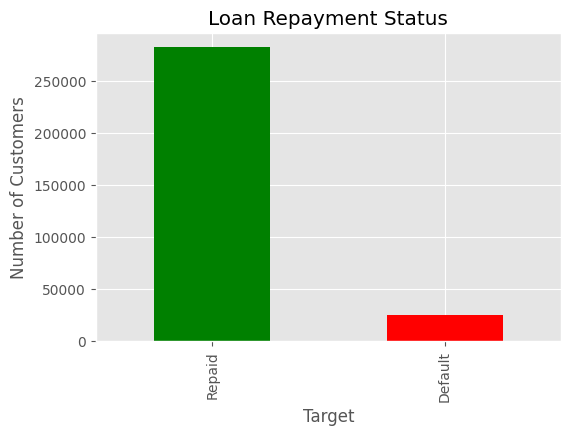

In [55]:
plt.figure(figsize=(6,4))

df["TARGET"].value_counts().plot(
    kind="bar",
    color=["green","red"]
)

plt.title("Loan Repayment Status")
plt.xlabel("Target")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["Repaid","Default"])

plt.show()

In [56]:
# Business Insight

# The dataset is highly imbalanced.
# Most customers successfully repaid their loans, while only a small percentage defaulted.

# This indicates that loan defaults are relatively rare events, which is an important consideration
# for predictive modeling and risk assessment.

In [57]:
# Analysis 2: Gender vs Loan Default

# This analysis examines whether loan default rates differ between male and female applicants. 
# Understanding gender-wise repayment behavior helps identify any significant differences in default risk.

In [58]:
df["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

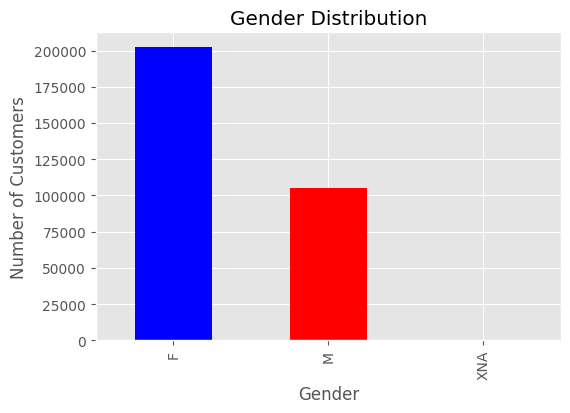

In [59]:
plt.figure(figsize=(6,4))

df["CODE_GENDER"].value_counts().plot(
    kind="bar",
    color=["blue", "red", "gray"]
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [60]:
gender_default = pd.crosstab(df["CODE_GENDER"],df["TARGET"],normalize="index") * 100
gender_default

TARGET,0,1
CODE_GENDER,,
F,93.000672,6.999328
M,89.858080,10.141920
XNA,100.000000,0.000000


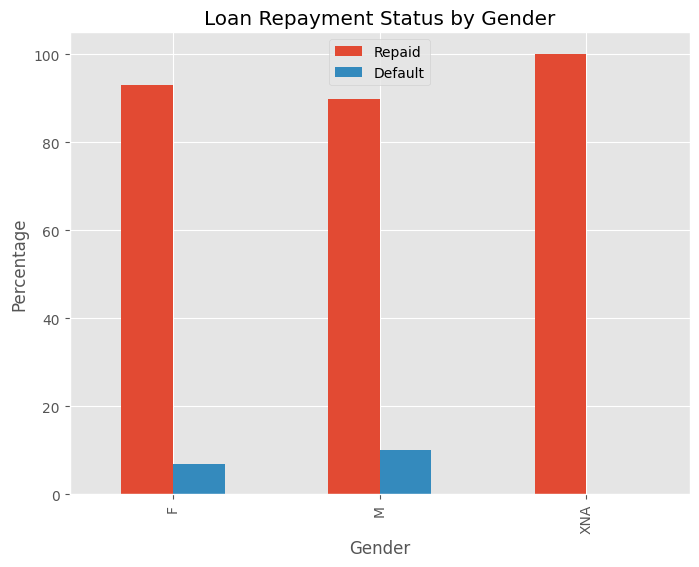

In [61]:
gender_default.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Loan Repayment Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")

plt.legend(["Repaid", "Default"])

plt.show()

In [62]:
# Business Insight

# The analysis compares loan repayment behavior across different genders.
# The results help determine whether male or female applicants exhibit higher default rates. 
# These insights can support portfolio risk assessment while recognizing that lending decisions should 
# remain fair and comply with applicable regulations.

In [63]:
# Analysis 3: Annual Income Distribution
# This analysis explores the distribution of customers' annual income to understand the financial profile of loan applicants.

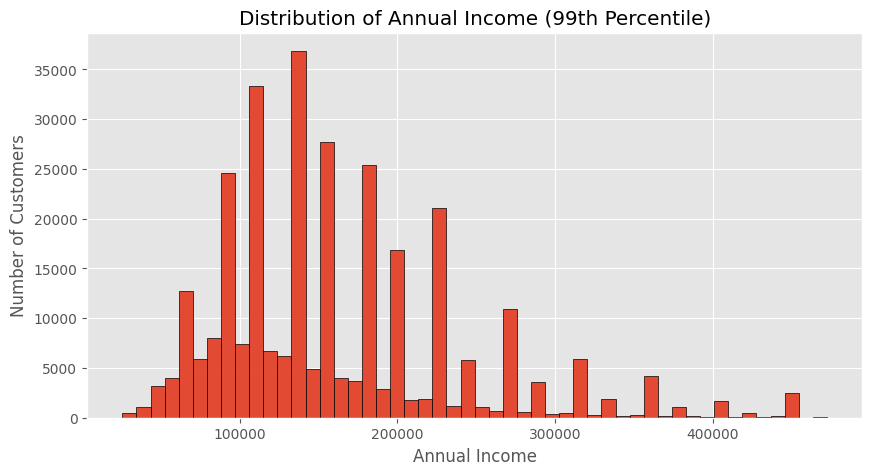

In [64]:
plt.figure(figsize=(10,5))

income_limit = df["AMT_INCOME_TOTAL"].quantile(0.99)

plt.hist(
    df[df["AMT_INCOME_TOTAL"] <= income_limit]["AMT_INCOME_TOTAL"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Annual Income (99th Percentile)")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

In [65]:
df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [66]:
# Business Insight
""" The annual income distribution is highly right-skewed due to a small number of applicants with 
exceptionally high incomes. To improve visualization, the histogram is limited to the 99th percentile, 
providing a clearer view of the income distribution for the majority of applicants. """

' The annual income distribution is highly right-skewed due to a small number of applicants with \nexceptionally high incomes. To improve visualization, the histogram is limited to the 99th percentile, \nproviding a clearer view of the income distribution for the majority of applicants. '

In [67]:
## 4.4 Age Distribution

# The dataset stores customer age as the number of days before the loan application date (`DAYS_BIRTH`).
# This analysis converts age into years to understand the age profile of loan applicants.

In [68]:
df["AGE"] = (-df["DAYS_BIRTH"] / 365).astype(int)

In [69]:
df["AGE"].head()

0    25
1    45
2    52
3    52
4    54
Name: AGE, dtype: int32

In [70]:
df["AGE"].describe()

count    307511.000000
mean         43.435968
std          11.954593
min          20.000000
25%          34.000000
50%          43.000000
75%          53.000000
max          69.000000
Name: AGE, dtype: float64

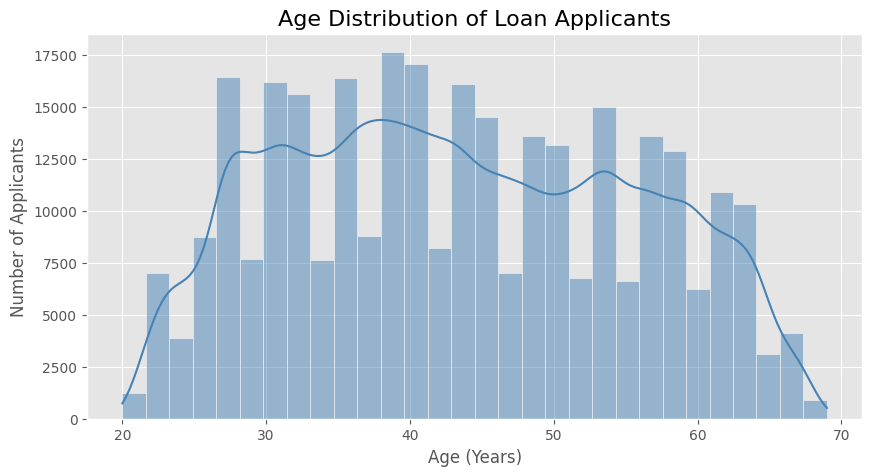

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="AGE",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution of Loan Applicants", fontsize=16)
plt.xlabel("Age (Years)")
plt.ylabel("Number of Applicants")

plt.show()

In [72]:
df["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

In [73]:
# Business Insight
# Most applicants request small to medium-sized loans, while a relatively small number apply for very large loan 
# amounts. This right-skewed distribution suggests that high-value loans are less common in the portfolio.

In [74]:
# 4.5 Loan Amount Distribution

# This analysis explores the distribution of loan amounts requested by applicants. 
# Understanding the loan amount distribution helps identify common borrowing patterns and detect unusually 
# large loan requests.

In [75]:
df["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

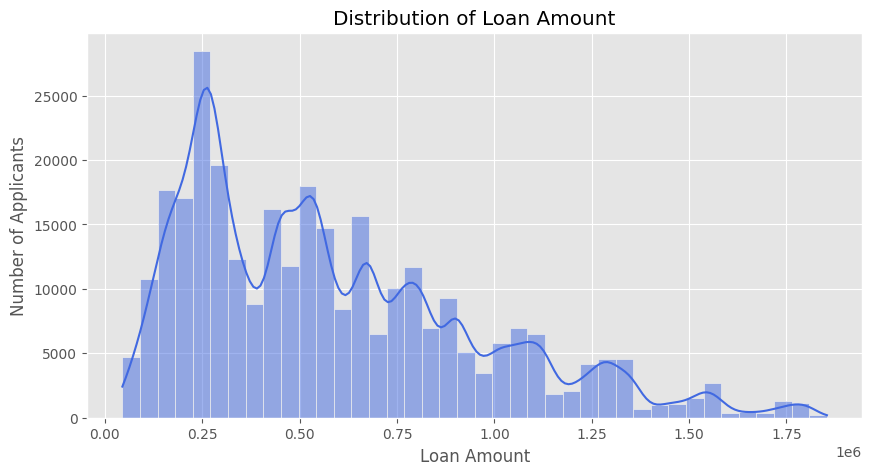

In [76]:
plt.figure(figsize=(10,5))

credit_limit = df["AMT_CREDIT"].quantile(0.99)

sns.histplot(
    data=df[df["AMT_CREDIT"] <= credit_limit],
    x="AMT_CREDIT",
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.show()

In [77]:
#  Business Insight

# Most applicants request small to medium-sized loans, while only a limited number apply for very large loan amounts. 
# The presence of high-value loans creates a right-skewed distribution, indicating that large loans are relatively uncommon.

In [78]:
# 4.6 Education Level

# This analysis examines the educational background of applicants to understand the composition of the customer 
# base.

In [79]:
education = df["NAME_EDUCATION_TYPE"].value_counts()

education

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

C:\Users\darsh\AppData\Local\Temp\ipykernel_24304\298044806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
F:\ANACONDA\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
F:\ANACONDA\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
F:\ANACONDA\Lib

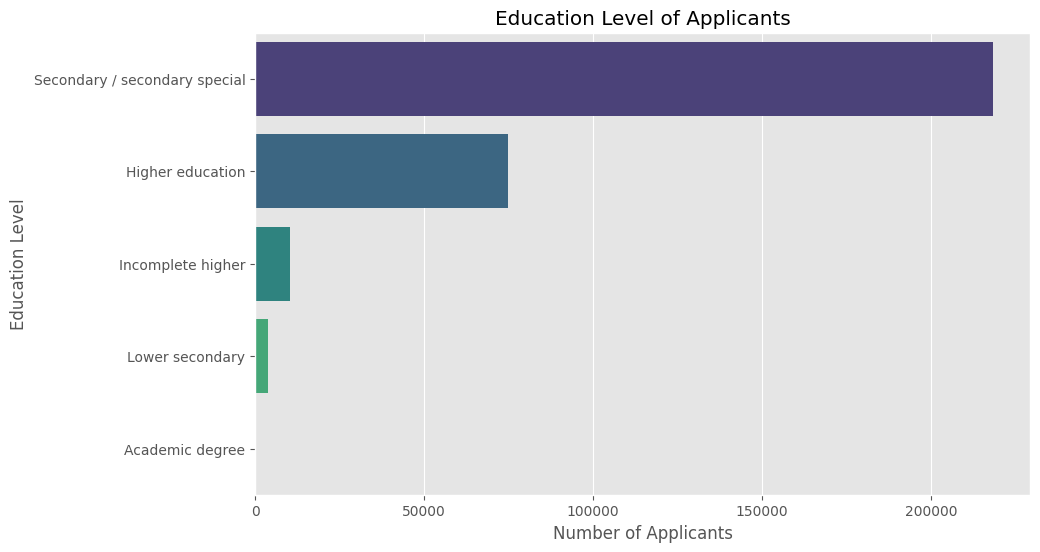

In [80]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="NAME_EDUCATION_TYPE",
    order=df["NAME_EDUCATION_TYPE"].value_counts().index,
    palette="viridis"
)

plt.title("Education Level of Applicants")
plt.xlabel("Number of Applicants")
plt.ylabel("Education Level")

plt.show()

In [81]:
# ### Business Insight

# Most applicants have completed secondary education, while a smaller proportion hold higher education degrees.
# Understanding the education profile helps provide context for the applicant population and may support further 
# analysis of repayment behavior.

In [82]:
## 4.5 Loan Amount Distribution

# This analysis explores the distribution of loan amounts requested by applicants. 
# Understanding loan amount patterns helps identify common borrowing behavior and detect unusually large loan requests.

In [83]:
df["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

F:\ANACONDA\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


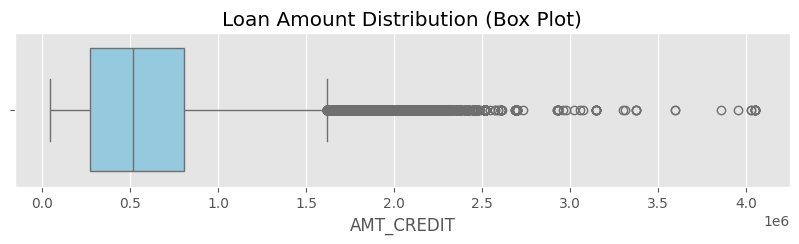

In [84]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["AMT_CREDIT"],
    color="skyblue"
)

plt.title("Loan Amount Distribution (Box Plot)")

plt.show()

In [85]:
# ### Business Insight

# Most applicants request small to medium-sized loans, while only a limited number apply for very large loan amounts. 
# The distribution is right-skewed because a few high-value loans increase the maximum loan amount considerably.

In [86]:
# 4.6 Education Level

# This analysis examines the educational background of applicants. 
# Education level may influence employment opportunities, income levels, and ultimately the ability to repay loans.

In [87]:
education = df["NAME_EDUCATION_TYPE"].value_counts()

education

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

F:\ANACONDA\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
F:\ANACONDA\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
F:\ANACONDA\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get

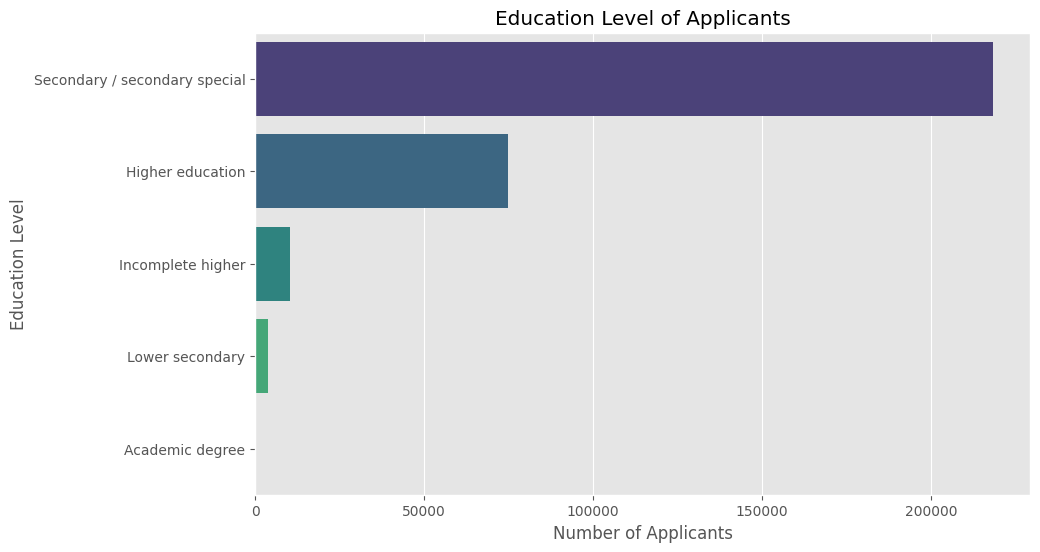

In [88]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="NAME_EDUCATION_TYPE",
    order=df["NAME_EDUCATION_TYPE"].value_counts().index,
    hue="NAME_EDUCATION_TYPE",
    palette="viridis",
    legend=False
)

plt.title("Education Level of Applicants")
plt.xlabel("Number of Applicants")
plt.ylabel("Education Level")

plt.show()

In [89]:
round(df["NAME_EDUCATION_TYPE"].value_counts(normalize=True) * 100, 2)

NAME_EDUCATION_TYPE
Secondary / secondary special    71.02
Higher education                 24.34
Incomplete higher                 3.34
Lower secondary                   1.24
Academic degree                   0.05
Name: proportion, dtype: float64

In [90]:
# Business Insight
# Most applicants have completed secondary education, making it the dominant educational background in the loan portfolio. 
# Applicants with higher education represent a smaller share, while academic degree holders form only a very small
# proportion of the customer base.

In [91]:
# 4.7 Occupation Type

# This analysis explores the occupations of loan applicants. Understanding the occupation profile helps identify which employment groups 
# constitute the majority of borrowers.

In [92]:
occupation = df["OCCUPATION_TYPE"].value_counts()
occupation

OCCUPATION_TYPE
Laborers                 151577
Sales staff               32102
Core staff                27570
Managers                  21371
Drivers                   18603
High skill tech staff     11380
Accountants                9813
Medicine staff             8537
Security staff             6721
Cooking staff              5946
Cleaning staff             4653
Private service staff      2652
Low-skill Laborers         2093
Waiters/barmen staff       1348
Secretaries                1305
Realty agents               751
HR staff                    563
IT staff                    526
Name: count, dtype: int64

In [93]:
round(df["OCCUPATION_TYPE"].value_counts(normalize=True) * 100, 2)

OCCUPATION_TYPE
Laborers                 49.29
Sales staff              10.44
Core staff                8.97
Managers                  6.95
Drivers                   6.05
High skill tech staff     3.70
Accountants               3.19
Medicine staff            2.78
Security staff            2.19
Cooking staff             1.93
Cleaning staff            1.51
Private service staff     0.86
Low-skill Laborers        0.68
Waiters/barmen staff      0.44
Secretaries               0.42
Realty agents             0.24
HR staff                  0.18
IT staff                  0.17
Name: proportion, dtype: float64

In [95]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

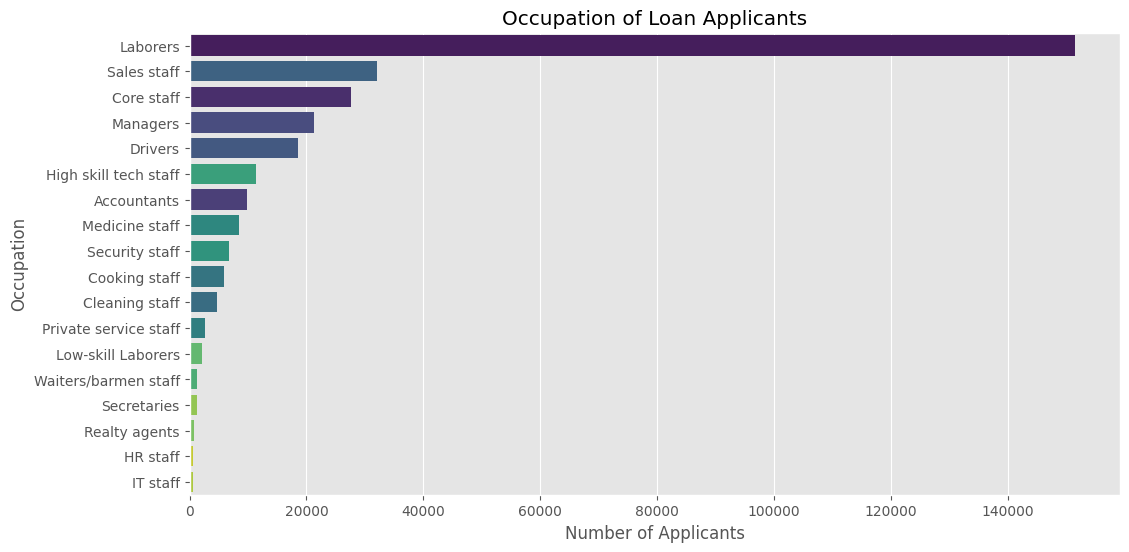

In [96]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="OCCUPATION_TYPE",
    order=df["OCCUPATION_TYPE"].value_counts().index,
    hue="OCCUPATION_TYPE",
    palette="viridis",
    legend=False
)

plt.title("Occupation of Loan Applicants")
plt.xlabel("Number of Applicants")
plt.ylabel("Occupation")

plt.show()

In [98]:
# ### Business Insight

# Laborers, sales staff, and core staff constitute the largest occupational groups among loan applicants. 
# Some occupation categories have relatively few applicants, indicating that the customer base is concentrated within a limited number of professions.

In [99]:
## 4.8 Income Type
# This analysis examines the primary source of income for applicants, providing insights into the employment and financial background of customers.

In [100]:
income_type = df["NAME_INCOME_TYPE"].value_counts()

income_type

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [101]:
round(df["NAME_INCOME_TYPE"].value_counts(normalize=True) * 100, 2)

NAME_INCOME_TYPE
Working                 51.63
Commercial associate    23.29
Pensioner               18.00
State servant            7.06
Unemployed               0.01
Student                  0.01
Businessman              0.00
Maternity leave          0.00
Name: proportion, dtype: float64

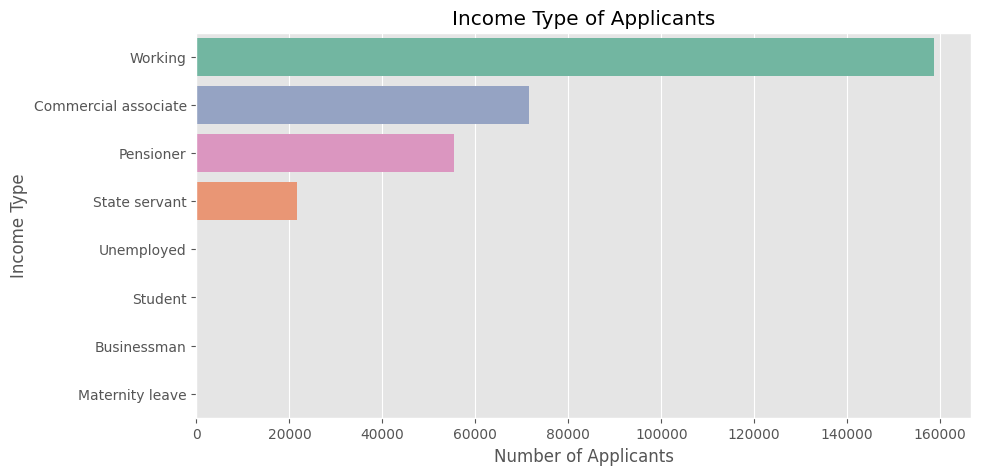

In [102]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="NAME_INCOME_TYPE",
    order=df["NAME_INCOME_TYPE"].value_counts().index,
    hue="NAME_INCOME_TYPE",
    palette="Set2",
    legend=False
)

plt.title("Income Type of Applicants")
plt.xlabel("Number of Applicants")
plt.ylabel("Income Type")

plt.show()

In [103]:
### Business Insight

# Most applicants earn income through employment, making salaried individuals the largest customer segment.
# Pensioners and commercial associates also represent a significant portion of the applicant population.

In [104]:
## 4.9 Correlation Analysis
# Correlation analysis helps identify relationships between important numerical variables such as income, credit amount, annuity, and age.

In [105]:
corr_columns = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "AGE"
]

corr = df[corr_columns].corr()

corr

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AGE
TARGET,1.000000,-0.003982,-0.030369,-0.012815,-0.039623,-0.078234
AMT_INCOME_TOTAL,-0.003982,1.000000,0.156870,0.191657,0.159632,-0.027226
AMT_CREDIT,-0.030369,0.156870,1.000000,0.770127,0.986734,0.055408
AMT_ANNUITY,-0.012815,0.191657,0.770127,1.000000,0.774837,-0.009453
AMT_GOODS_PRICE,-0.039623,0.159632,0.986734,0.774837,1.000000,0.053484
AGE,-0.078234,-0.027226,0.055408,-0.009453,0.053484,1.000000


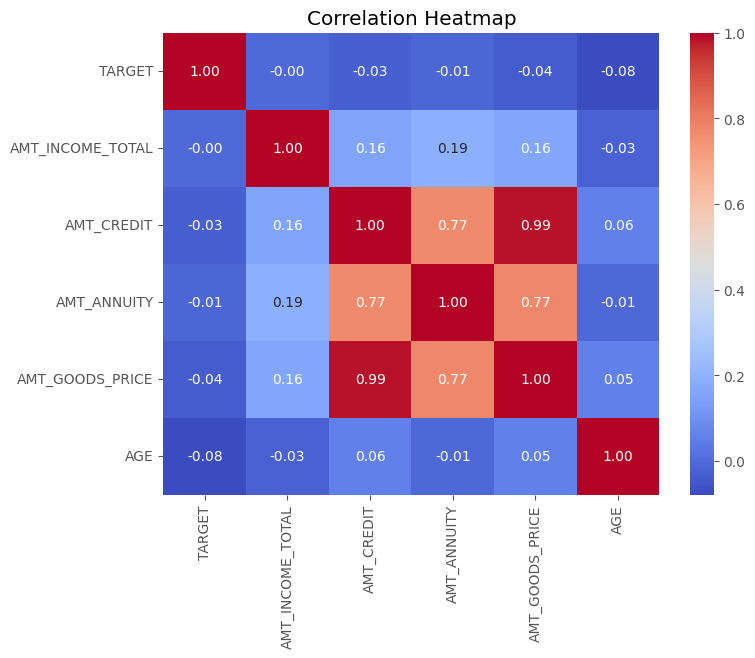

In [106]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [107]:
# Business Insight

# Loan amount, annuity amount, and goods price exhibit strong positive correlations, indicating that larger loans are generally associated with 
# higher installment payments and more expensive purchased goods. Income shows a weaker positive relationship with loan amount, suggesting that higher-income
# applicants tend to request larger loans.

In [108]:
# 4.10 Key Business Insights

# Key Findings

# - Most applicants successfully repay their loans, while loan defaults account for only a small proportion of the dataset.
# - The applicant population is concentrated between approximately 25 and 55 years of age.
# - Annual income and loan amount distributions are positively skewed due to a small number of high-value applicants.
# - Secondary education is the most common educational background among borrowers.
# - Salaried employees constitute the largest customer segment.
# - Laborers, sales staff, and core staff are the most common occupations.
# - Loan amount, annuity, and goods price show strong positive correlations.
# - These insights provide valuable information for understanding customer profiles and supporting future credit risk modeling.